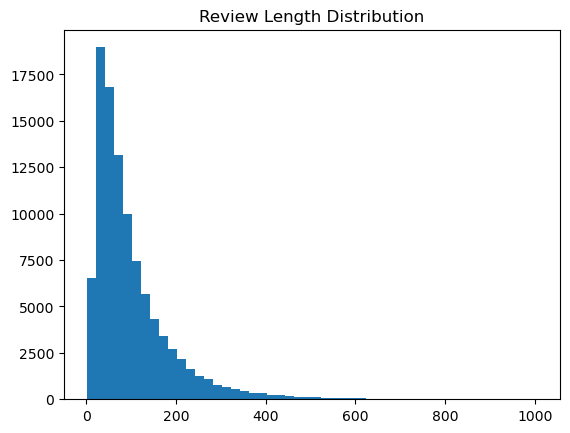

In [8]:
import json
import matplotlib.pyplot as plt

lengths = []

with open(r"D:\\IR\\demo\\data\\review.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line)
        lengths.append(len(data["text"].split()))

plt.hist(lengths, bins=50)
plt.title("Review Length Distribution")
plt.show()

In [9]:
#hiển thị xem có bao nhiêu lable pos và neg
label_counts = {"positive": 0, "negative": 0}
with open(r"D:\\IR\\demo\\data\\processed\\review_labeled.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line)
        label_counts[data["label"]] += 1
print(label_counts)

{'positive': 69729, 'negative': 18909}


In [10]:
# mô hình Logistic Regression và Naive Bayes base k có tham số 
import json
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
def load_data(file_path):
    texts = []
    labels = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            data = json.loads(line)
            texts.append(data["text"])
            labels.append(data["label"])
    return texts, labels
def train_and_evaluate(texts, labels):
    X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)
    vectorizer = TfidfVectorizer(max_features=5000)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
def train_naive_bayes(texts, labels):
    X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)
    vectorizer = TfidfVectorizer(max_features=5000)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    model = MultinomialNB()
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    print(classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
#so sánh giữa 2 model
if __name__ == "__main__":
    INPUT_FILE = r"D:\IR\demo\data\processed\review_labeled.jsonl"
    texts, labels = load_data(INPUT_FILE)

    print("=== Logistic Regression ===")
    train_and_evaluate(texts, labels)

    print("\n=== Naive Bayes ===")
    train_naive_bayes(texts, labels)

=== Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.93      0.84      0.89      3783
    positive       0.96      0.98      0.97     13945

    accuracy                           0.95     17728
   macro avg       0.95      0.91      0.93     17728
weighted avg       0.95      0.95      0.95     17728

Accuracy: 0.9535762635379061

=== Naive Bayes ===
              precision    recall  f1-score   support

    negative       0.92      0.61      0.73      3783
    positive       0.90      0.99      0.94     13945

    accuracy                           0.91     17728
   macro avg       0.91      0.80      0.84     17728
weighted avg       0.91      0.91      0.90     17728

Accuracy: 0.9060807761732852


In [11]:
import json

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


# =========================
# 1. Load data (đã labeled sẵn)
# =========================
def load_data(file_path):
    texts = []
    labels = []

    label_map = {
        "negative": 0,
        "positive": 1
    }

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            data = json.loads(line)

            texts.append(data["text"])
            labels.append(label_map[data["label"]])

    return texts, labels


# =========================
# 2. Train + Evaluate
# =========================
def train_and_evaluate(texts, labels):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=30000,
        min_df=2,
        max_df=0.9
    )

    X = vectorizer.fit_transform(texts)
    y = labels

    # Stratified split (QUAN TRỌNG)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Logistic Regression (fix imbalance)
    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("=" * 50)
    print("Logistic Regression")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

In [12]:
from sklearn.naive_bayes import MultinomialNB


def train_naive_bayes(texts, labels):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=30000,
        min_df=2,
        max_df=0.9
    )

    X = vectorizer.fit_transform(texts)
    y = labels

    # stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # train NB
    nb = MultinomialNB()
    nb.fit(X_train, y_train)

    y_pred = nb.predict(X_test)

    print("=" * 50)
    print("Naive Bayes")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

In [13]:
# so sánh giữa 2 model
if __name__ == "__main__":
    INPUT_FILE = r"D:\IR\demo\data\processed\review_labeled.jsonl"
    texts, labels = load_data(INPUT_FILE)

    train_and_evaluate(texts, labels)
    train_naive_bayes(texts, labels)

Logistic Regression
Accuracy: 0.9518840252707581
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      3782
           1       0.98      0.95      0.97     13946

    accuracy                           0.95     17728
   macro avg       0.92      0.95      0.93     17728
weighted avg       0.96      0.95      0.95     17728

Naive Bayes
Accuracy: 0.9328745487364621
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      3782
           1       0.94      0.97      0.96     13946

    accuracy                           0.93     17728
   macro avg       0.92      0.88      0.90     17728
weighted avg       0.93      0.93      0.93     17728



In [14]:
# lưu model đã train vào D:\IR\demo\models\tên model_vectorizer.joblib
import joblib
import os
def save_model(model, vectorizer, model_name):
    model_dir = "D:\\IR\\demo\\models"
    if not os.path.exists(model_dir):
        os.makedirs(model_dir)

    model_path = os.path.join(model_dir, f"{model_name}.joblib")
    vectorizer_path = os.path.join(model_dir, f"{model_name}_vectorizer.joblib")

    joblib.dump(model, model_path)
    joblib.dump(vectorizer, vectorizer_path)

    print(f"Model saved to {model_path}")
    print(f"Vectorizer saved to {vectorizer_path}")
# lưu model regression vào D:\IR\demo\models\logistic_regression.joblib
if __name__ == "__main__":
    INPUT_FILE = r"D:\IR\demo\data\processed\review_labeled.jsonl"
    texts, labels = load_data(INPUT_FILE)

    # Train Logistic Regression
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=30000,
        min_df=2,
        max_df=0.9
    )
    X = vectorizer.fit_transform(texts)
    y = labels

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    )
    model.fit(X_train, y_train)

    # Save model and vectorizer
    save_model(model, vectorizer, "logistic_regression")

Model saved to D:\IR\demo\models\logistic_regression.joblib
Vectorizer saved to D:\IR\demo\models\logistic_regression_vectorizer.joblib


In [15]:
#test thử data mới
new_texts = [
    "This product is amazing!",
    "I hate this product.",
    "The sushi here is cheap and surprisingly fresh, I really enjoyed it",
    "The service was terrible, the staff ignored us for 30 minutes.",
    "Cozy cafe with very friendly staff and good coffee",
    "The hotel room was clean and comfortable, had a great stay",
    "Quiet place to eat, perfect for relaxing after work",
    "The food is good but the service is very slow",
]
# load model và vectorizer đã lưu
model_path = r"D:\IR\demo\models\logistic_regression.joblib"
vectorizer_path = r"D:\IR\demo\models\logistic_regression_vectorizer.joblib"
model = joblib.load(model_path)
vectorizer = joblib.load(vectorizer_path)
# vectorize new texts
new_X = vectorizer.transform(new_texts)
# predict
predictions = model.predict(new_X)
label_map = {0: "negative", 1: "positive"}
for text, pred in zip(new_texts, predictions):
    print(f"Text: {text}\nPredicted Label: {label_map[pred]}\n")

Text: This product is amazing!
Predicted Label: positive

Text: I hate this product.
Predicted Label: negative

Text: The sushi here is cheap and surprisingly fresh, I really enjoyed it
Predicted Label: positive

Text: The service was terrible, the staff ignored us for 30 minutes.
Predicted Label: negative

Text: Cozy cafe with very friendly staff and good coffee
Predicted Label: positive

Text: The hotel room was clean and comfortable, had a great stay
Predicted Label: positive

Text: Quiet place to eat, perfect for relaxing after work
Predicted Label: positive

Text: The food is good but the service is very slow
Predicted Label: negative



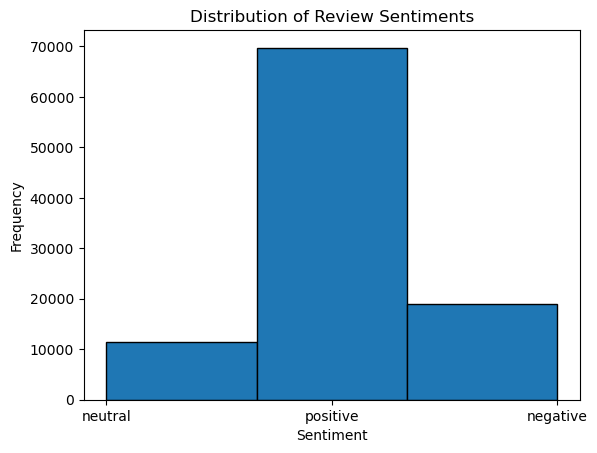

{'positive': 69729, 'negative': 18909, 'neutral': 11362}


In [16]:
import json
import matplotlib.pyplot as plt

#Xem phân bố dữ liệu của data D:\IR\demo\data\processed\processed_review.jsonl vẽ biểu đồ phân bố sentiment của review
with open(r"D:\IR\demo\data\processed\processed_review.jsonl", "r", encoding="utf-8") as f:
    sentiments = []
    for line in f:
        data = json.loads(line)
        sentiments.append(data["sentiment"])

plt.hist(sentiments, bins=3, edgecolor="black")
plt.xlabel("Sentiment")
plt.ylabel("Frequency")
plt.title("Distribution of Review Sentiments")
plt.show()

# in ra xem có bao nhiêu review có sentiment là positive, negative, neutral
sentiment_counts = {"positive": 0, "negative": 0, "neutral": 0}
with open(r"D:\IR\demo\data\processed\processed_review.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line)
        sentiment_counts[data["sentiment"]] += 1
print(sentiment_counts)

In [17]:
#tối ưu hóa mô hình Naive Bayes bằng cách thêm tham số alpha chạy xem số alpha nào cho kết quả tốt nhất
def train_naive_bayes_with_alpha(texts, labels, alpha):
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=30000,
        min_df=2,
        max_df=0.9
    )

    X = vectorizer.fit_transform(texts)
    y = labels

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = MultinomialNB(alpha=alpha)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(f"Alpha: {alpha}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

In [18]:
# thử với các giá trị alpha khác nhau
alphas = [0.1, 0.5, 1.0, 5.0, 10.0]
for alpha in alphas:
    train_naive_bayes_with_alpha(texts, labels, alpha)

Alpha: 0.1
Accuracy: 0.9373871841155235
              precision    recall  f1-score   support

           0       0.89      0.80      0.85      3782
           1       0.95      0.97      0.96     13946

    accuracy                           0.94     17728
   macro avg       0.92      0.89      0.90     17728
weighted avg       0.94      0.94      0.94     17728

Alpha: 0.5
Accuracy: 0.9364846570397112
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      3782
           1       0.95      0.97      0.96     13946

    accuracy                           0.94     17728
   macro avg       0.92      0.89      0.90     17728
weighted avg       0.94      0.94      0.94     17728

Alpha: 1.0
Accuracy: 0.9328745487364621
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      3782
           1       0.94      0.97      0.96     13946

    accuracy                           0.93     17728
   macro